# Notebook 05 — Transfer Learning

This notebook applies transfer learning to classify 64×64 RGB satellite images into four classes:
**cloudy**, **desert**, **green_area**, **water**.

Two pretrained backbones are fine-tuned using a two-phase strategy:
1. **Phase 1** — Train only the new classification head (backbone frozen).
2. **Phase 2** — Unfreeze all layers and fine-tune with a lower learning rate.

Models evaluated:
- ResNet-18
- EfficientNet-B0

Final test-set evaluation is deferred to Notebook 06.

## 1. Setup & Data Loading

In [1]:
import random
import json
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.models as tv_models
import torchvision.transforms as T

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print('Imports OK')

Imports OK


In [2]:
# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ───────────────────────────────────────────────────────────────────
device = torch.device(
    'mps'  if torch.backends.mps.is_available()  else
    'cuda' if torch.cuda.is_available()           else
    'cpu'
)
print(f'Device: {device}')

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR     = Path('..').resolve()
DATA_DIR     = BASE_DIR / 'data_preprocessed'
RESULTS_DIR  = BASE_DIR / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Data dir    : {DATA_DIR}')
print(f'Results dir : {RESULTS_DIR}')

Device: mps
Data dir    : /Users/michelangelonardi/Desktop/Università/Master/BocconiMaster/Year2/Semester2_UW/AI_for_Agriculture/FinalProject/AI_agri_project/data_preprocessed
Results dir : /Users/michelangelonardi/Desktop/Università/Master/BocconiMaster/Year2/Semester2_UW/AI_for_Agriculture/FinalProject/AI_agri_project/results


In [3]:
# ── Load arrays ───────────────────────────────────────────────────────────────
X_train_full = np.load(DATA_DIR / 'X_train.npy')   # (N, 64, 64, 3)  float32  [0,1]
y_train_full = np.load(DATA_DIR / 'y_train.npy')   # (N,)  int
X_test       = np.load(DATA_DIR / 'X_test.npy')
y_test       = np.load(DATA_DIR / 'y_test.npy')

with open(DATA_DIR / 'class_mapping.json') as f:
    class_mapping = json.load(f)

idx_to_class = {int(k): v for k, v in class_mapping['idx_to_class'].items()}
CLASSES      = ['cloudy', 'desert', 'green_area', 'water']
NUM_CLASSES  = len(CLASSES)

print(f'X_train_full : {X_train_full.shape}  dtype={X_train_full.dtype}')
print(f'X_test       : {X_test.shape}')
print(f'Classes      : {CLASSES}')
print(f'idx_to_class : {idx_to_class}')

X_train_full : (4800, 64, 64, 3)  dtype=float32
X_test       : (1200, 64, 64, 3)
Classes      : ['cloudy', 'desert', 'green_area', 'water']
idx_to_class : {0: 'cloudy', 1: 'desert', 2: 'green_area', 3: 'water'}


In [4]:
# ── Train / Validation split (80/20 stratified) ───────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2, stratify=y_train_full, random_state=SEED
)

print(f'Train : {X_train.shape}  |  Val : {X_val.shape}  |  Test : {X_test.shape}')

# Class distribution in each split
for name, y in [('train', y_train), ('val', y_val), ('test', y_test)]:
    unique, counts = np.unique(y, return_counts=True)
    dist = {idx_to_class[u]: c for u, c in zip(unique, counts)}
    print(f'  {name:5s} distribution: {dist}')

Train : (3840, 64, 64, 3)  |  Val : (960, 64, 64, 3)  |  Test : (1200, 64, 64, 3)
  train distribution: {'cloudy': 960, 'desert': 960, 'green_area': 960, 'water': 960}
  val   distribution: {'cloudy': 240, 'desert': 240, 'green_area': 240, 'water': 240}
  test  distribution: {'cloudy': 300, 'desert': 300, 'green_area': 300, 'water': 300}


## 2. Data Augmentation & DataLoaders

In [5]:
class SatelliteDataset(Dataset):
    """
    Wraps numpy arrays (N, H, W, C) in [0,1] as a PyTorch Dataset.
    Returns (image_tensor [3,H,W], label).
    """
    def __init__(self, images: np.ndarray, labels: np.ndarray, transform=None):
        self.images    = images          # float32 [0,1] HWC
        self.labels    = labels.astype(np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img   = self.images[idx]         # (H, W, C)  float32
        label = int(self.labels[idx])

        if self.transform is not None:
            img = self.transform(img)
        else:
            # Default: HWC -> CHW tensor
            img = torch.from_numpy(img).permute(2, 0, 1)   # (3, H, W)

        return img, label


# ── Helper: numpy HWC float32 [0,1]  →  torch CHW float32 ────────────────────
class NumpyToTensor:
    """Convert a (H,W,C) numpy float32 [0,1] array to a (C,H,W) FloatTensor."""
    def __call__(self, img: np.ndarray) -> torch.Tensor:
        return torch.from_numpy(img).permute(2, 0, 1).float()


# ── Transforms ────────────────────────────────────────────────────────────────
# Data is already normalised to [0,1] → do NOT apply ImageNet mean/std.

train_transform = T.Compose([
    NumpyToTensor(),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
])

val_transform = T.Compose([
    NumpyToTensor(),
])

print('Transforms defined.')

Transforms defined.


In [6]:
BATCH_SIZE = 32

train_ds = SatelliteDataset(X_train, y_train, transform=train_transform)
val_ds   = SatelliteDataset(X_val,   y_val,   transform=val_transform)
test_ds  = SatelliteDataset(X_test,  y_test,  transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Quick sanity check
xb, yb = next(iter(train_loader))
print(f'Batch shape : {xb.shape}  dtype={xb.dtype}  min={xb.min():.3f}  max={xb.max():.3f}')
print(f'Labels      : {yb[:8].tolist()}')

Batch shape : torch.Size([32, 3, 64, 64])  dtype=torch.float32  min=0.000  max=1.000
Labels      : [2, 1, 3, 1, 0, 0, 3, 1]


## 3. Transfer Learning — ResNet-18

In [7]:
# ── Shared training utilities ─────────────────────────────────────────────────

def train_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        loss   = loss_fn(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == y_batch).sum().item()
        total      += y_batch.size(0)
    return total_loss / total, correct / total


def validate(model, loader, loss_fn, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss   = loss_fn(logits, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            preds       = logits.argmax(dim=1)
            correct    += (preds == y_batch).sum().item()
            total      += y_batch.size(0)
    return total_loss / total, correct / total


def get_predictions(model, loader, device):
    """Return (all_preds, all_labels) arrays."""
    model.eval()
    preds_list, labels_list = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits  = model(X_batch)
            preds_list.append(logits.argmax(dim=1).cpu().numpy())
            labels_list.append(y_batch.numpy())
    return np.concatenate(preds_list), np.concatenate(labels_list)


print('Training utilities defined.')

Training utilities defined.


In [8]:
# ── Build ResNet-18 ───────────────────────────────────────────────────────────
resnet = tv_models.resnet18(weights=tv_models.ResNet18_Weights.DEFAULT)

# Freeze all backbone parameters
for param in resnet.parameters():
    param.requires_grad = False

# Replace classifier head
resnet.fc = nn.Linear(512, NUM_CLASSES)

resnet = resnet.to(device)

total_params     = sum(p.numel() for p in resnet.parameters())
trainable_params = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f'ResNet-18 loaded')
print(f'  Total params     : {total_params:,}')
print(f'  Trainable params : {trainable_params:,}  (head only)')
print(f'  Frozen params    : {frozen_params:,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/michelangelonardi/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:02<00:00, 21.6MB/s]


ResNet-18 loaded
  Total params     : 11,178,564
  Trainable params : 2,052  (head only)
  Frozen params    : 11,176,512


In [9]:
# ── Phase 1 — Head-only training (10 epochs) ──────────────────────────────────
print('=' * 60)
print('ResNet-18  Phase 1: Head-only training')
print('=' * 60)

loss_fn_rn   = nn.CrossEntropyLoss()
optimizer_p1 = optim.Adam(resnet.fc.parameters(), lr=0.001)

P1_EPOCHS       = 10
PATIENCE_P1     = 5

rn_history_p1 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

best_val_loss_p1 = float('inf')
patience_counter = 0

for epoch in range(1, P1_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_epoch(resnet, train_loader, loss_fn_rn, optimizer_p1, device)
    vl_loss, vl_acc = validate(resnet, val_loader,   loss_fn_rn, device)
    elapsed = time.time() - t0

    rn_history_p1['train_loss'].append(tr_loss)
    rn_history_p1['val_loss'].append(vl_loss)
    rn_history_p1['train_acc'].append(tr_acc)
    rn_history_p1['val_acc'].append(vl_acc)

    print(f'  Epoch {epoch:02d}/{P1_EPOCHS}  '
          f'train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  '
          f'val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}  '
          f'({elapsed:.1f}s)')

    if vl_loss < best_val_loss_p1:
        best_val_loss_p1 = vl_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE_P1:
            print(f'  Early stopping triggered at epoch {epoch}')
            break

print(f'Phase 1 complete. Best val loss: {best_val_loss_p1:.4f}')

ResNet-18  Phase 1: Head-only training
  Epoch 01/10  train_loss=0.6499  train_acc=0.7604  val_loss=0.7814  val_acc=0.7635  (4.6s)
  Epoch 02/10  train_loss=0.3784  train_acc=0.8594  val_loss=0.5474  val_acc=0.8500  (2.4s)
  Epoch 03/10  train_loss=0.2982  train_acc=0.8992  val_loss=0.4831  val_acc=0.8583  (2.4s)
  Epoch 04/10  train_loss=0.3035  train_acc=0.8901  val_loss=0.4469  val_acc=0.8688  (2.4s)
  Epoch 05/10  train_loss=0.2705  train_acc=0.9055  val_loss=0.4109  val_acc=0.8750  (2.4s)
  Epoch 06/10  train_loss=0.2586  train_acc=0.9036  val_loss=0.4011  val_acc=0.8688  (2.4s)
  Epoch 07/10  train_loss=0.2611  train_acc=0.9070  val_loss=0.4021  val_acc=0.8729  (2.4s)
  Epoch 08/10  train_loss=0.2512  train_acc=0.9081  val_loss=0.3589  val_acc=0.8990  (2.4s)
  Epoch 09/10  train_loss=0.2545  train_acc=0.9052  val_loss=0.3437  val_acc=0.8969  (2.4s)
  Epoch 10/10  train_loss=0.2466  train_acc=0.9135  val_loss=0.3420  val_acc=0.8990  (2.4s)
Phase 1 complete. Best val loss: 0.3420


In [10]:
# ── Phase 2 — Full fine-tuning (up to 30 epochs) ─────────────────────────────
print('=' * 60)
print('ResNet-18  Phase 2: Full fine-tuning')
print('=' * 60)

# Unfreeze all layers
for param in resnet.parameters():
    param.requires_grad = True

trainable_now = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f'Trainable params after unfreeze: {trainable_now:,}')

optimizer_p2 = optim.AdamW(resnet.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler_p2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p2, mode='min', patience=5, factor=0.5, verbose=False
)

P2_EPOCHS   = 30
PATIENCE_P2 = 8
RN_SAVE_PATH = RESULTS_DIR / 'best_resnet18_model.pth'

rn_history_p2    = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss_p2 = float('inf')
patience_counter = 0

for epoch in range(1, P2_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_epoch(resnet, train_loader, loss_fn_rn, optimizer_p2, device)
    vl_loss, vl_acc = validate(resnet, val_loader,   loss_fn_rn, device)
    elapsed = time.time() - t0

    scheduler_p2.step(vl_loss)

    rn_history_p2['train_loss'].append(tr_loss)
    rn_history_p2['val_loss'].append(vl_loss)
    rn_history_p2['train_acc'].append(tr_acc)
    rn_history_p2['val_acc'].append(vl_acc)

    print(f'  Epoch {epoch:02d}/{P2_EPOCHS}  '
          f'train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  '
          f'val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}  '
          f'lr={optimizer_p2.param_groups[0]["lr"]:.6f}  '
          f'({elapsed:.1f}s)')

    if vl_loss < best_val_loss_p2:
        best_val_loss_p2 = vl_loss
        patience_counter = 0
        torch.save(resnet.state_dict(), RN_SAVE_PATH)
        print(f'    ✓ Best model saved (val_loss={vl_loss:.4f})')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE_P2:
            print(f'  Early stopping triggered at epoch {epoch}')
            break

print(f'Phase 2 complete. Best val loss: {best_val_loss_p2:.4f}')
print(f'Best model saved to: {RN_SAVE_PATH}')

ResNet-18  Phase 2: Full fine-tuning
Trainable params after unfreeze: 11,178,564
  Epoch 01/30  train_loss=0.1498  train_acc=0.9482  val_loss=0.0765  val_acc=0.9729  lr=0.000100  (6.2s)
    ✓ Best model saved (val_loss=0.0765)
  Epoch 02/30  train_loss=0.1083  train_acc=0.9690  val_loss=0.1632  val_acc=0.9396  lr=0.000100  (4.8s)
  Epoch 03/30  train_loss=0.0555  train_acc=0.9833  val_loss=0.0127  val_acc=0.9969  lr=0.000100  (4.5s)
    ✓ Best model saved (val_loss=0.0127)
  Epoch 04/30  train_loss=0.0363  train_acc=0.9883  val_loss=0.0299  val_acc=0.9927  lr=0.000100  (4.5s)
  Epoch 05/30  train_loss=0.0596  train_acc=0.9854  val_loss=0.0208  val_acc=0.9979  lr=0.000100  (4.6s)
  Epoch 06/30  train_loss=0.0516  train_acc=0.9833  val_loss=0.0039  val_acc=0.9990  lr=0.000100  (4.6s)
    ✓ Best model saved (val_loss=0.0039)
  Epoch 07/30  train_loss=0.0301  train_acc=0.9904  val_loss=0.0164  val_acc=0.9979  lr=0.000100  (4.7s)
  Epoch 08/30  train_loss=0.0356  train_acc=0.9885  val_loss=

Best ResNet-18 weights loaded.


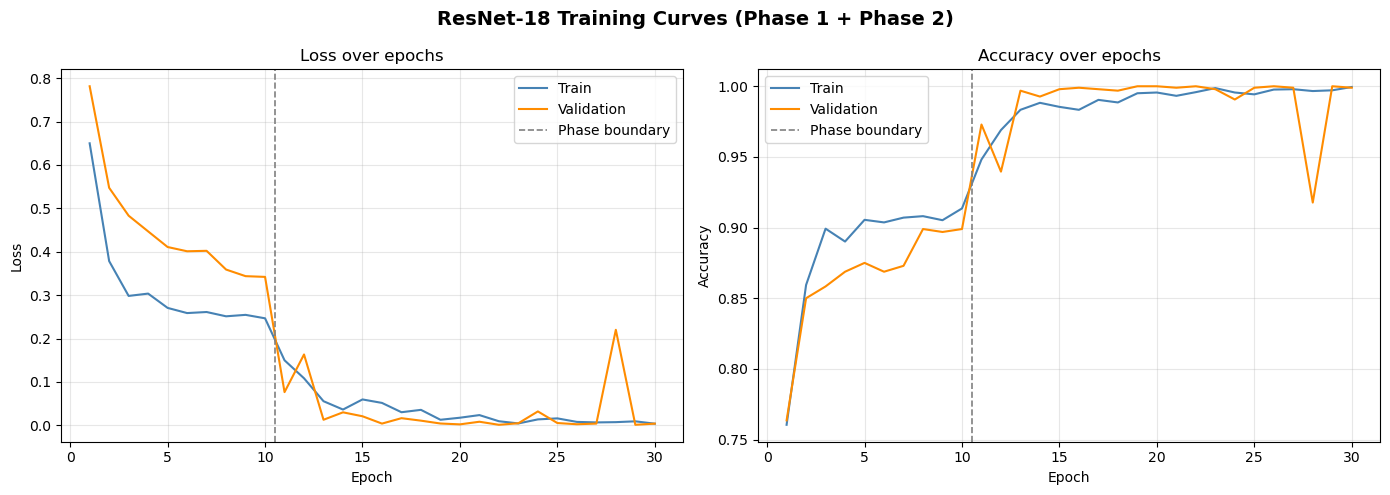

Saved: /Users/michelangelonardi/Desktop/Università/Master/BocconiMaster/Year2/Semester2_UW/AI_for_Agriculture/FinalProject/AI_agri_project/results/resnet18_training_curves.png


In [11]:
# ── Load best ResNet-18 weights ───────────────────────────────────────────────
resnet.load_state_dict(torch.load(RN_SAVE_PATH, map_location=device))
print('Best ResNet-18 weights loaded.')

# ── Plot training curves (Phase 1 + Phase 2 combined) ────────────────────────
rn_train_loss = rn_history_p1['train_loss'] + rn_history_p2['train_loss']
rn_val_loss   = rn_history_p1['val_loss']   + rn_history_p2['val_loss']
rn_train_acc  = rn_history_p1['train_acc']  + rn_history_p2['train_acc']
rn_val_acc    = rn_history_p1['val_acc']    + rn_history_p2['val_acc']
p1_len        = len(rn_history_p1['train_loss'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ResNet-18 Training Curves (Phase 1 + Phase 2)', fontsize=14, fontweight='bold')

epochs_all = range(1, len(rn_train_loss) + 1)

for ax, metric, ylabel in zip(
    axes,
    [(rn_train_loss, rn_val_loss),   (rn_train_acc, rn_val_acc)],
    ['Loss', 'Accuracy']
):
    train_m, val_m = metric
    ax.plot(epochs_all, train_m, label='Train',      color='steelblue')
    ax.plot(epochs_all, val_m,   label='Validation', color='darkorange')
    ax.axvline(p1_len + 0.5, color='gray', linestyle='--', linewidth=1.2, label='Phase boundary')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} over epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_path = RESULTS_DIR / 'resnet18_training_curves.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')

## 4. Transfer Learning — EfficientNet-B0

In [12]:
# ── Build EfficientNet-B0 ─────────────────────────────────────────────────────
effnet = tv_models.efficientnet_b0(weights=tv_models.EfficientNet_B0_Weights.DEFAULT)

# Freeze all backbone parameters
for param in effnet.parameters():
    param.requires_grad = False

# Replace classifier head  (features -> 1280 -> 4)
effnet.classifier[1] = nn.Linear(1280, NUM_CLASSES)

effnet = effnet.to(device)

total_params_en     = sum(p.numel() for p in effnet.parameters())
trainable_params_en = sum(p.numel() for p in effnet.parameters() if p.requires_grad)
frozen_params_en    = total_params_en - trainable_params_en

print(f'EfficientNet-B0 loaded')
print(f'  Total params     : {total_params_en:,}')
print(f'  Trainable params : {trainable_params_en:,}  (head only)')
print(f'  Frozen params    : {frozen_params_en:,}')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /Users/michelangelonardi/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 25.0MB/s]


EfficientNet-B0 loaded
  Total params     : 4,012,672
  Trainable params : 5,124  (head only)
  Frozen params    : 4,007,548


In [13]:
# ── Phase 1 — Head-only training ──────────────────────────────────────────────
print('=' * 60)
print('EfficientNet-B0  Phase 1: Head-only training')
print('=' * 60)

loss_fn_en   = nn.CrossEntropyLoss()
# Only optimise the new classifier layer
optimizer_en_p1 = optim.Adam(effnet.classifier.parameters(), lr=0.001)

en_history_p1    = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss_ep1 = float('inf')
patience_counter  = 0

for epoch in range(1, P1_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_epoch(effnet, train_loader, loss_fn_en, optimizer_en_p1, device)
    vl_loss, vl_acc = validate(effnet, val_loader,   loss_fn_en, device)
    elapsed = time.time() - t0

    en_history_p1['train_loss'].append(tr_loss)
    en_history_p1['val_loss'].append(vl_loss)
    en_history_p1['train_acc'].append(tr_acc)
    en_history_p1['val_acc'].append(vl_acc)

    print(f'  Epoch {epoch:02d}/{P1_EPOCHS}  '
          f'train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  '
          f'val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}  '
          f'({elapsed:.1f}s)')

    if vl_loss < best_val_loss_ep1:
        best_val_loss_ep1 = vl_loss
        patience_counter  = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE_P1:
            print(f'  Early stopping triggered at epoch {epoch}')
            break

print(f'Phase 1 complete. Best val loss: {best_val_loss_ep1:.4f}')

EfficientNet-B0  Phase 1: Head-only training
  Epoch 01/10  train_loss=0.5665  train_acc=0.8216  val_loss=0.4805  val_acc=0.8635  (6.0s)
  Epoch 02/10  train_loss=0.2975  train_acc=0.9078  val_loss=0.4210  val_acc=0.8719  (3.9s)
  Epoch 03/10  train_loss=0.2826  train_acc=0.9115  val_loss=0.3403  val_acc=0.8917  (3.8s)
  Epoch 04/10  train_loss=0.2623  train_acc=0.9117  val_loss=0.3341  val_acc=0.8885  (3.8s)
  Epoch 05/10  train_loss=0.2326  train_acc=0.9221  val_loss=0.2986  val_acc=0.9010  (3.8s)
  Epoch 06/10  train_loss=0.2439  train_acc=0.9138  val_loss=0.2895  val_acc=0.9062  (3.9s)
  Epoch 07/10  train_loss=0.2293  train_acc=0.9198  val_loss=0.3364  val_acc=0.8812  (4.1s)
  Epoch 08/10  train_loss=0.2278  train_acc=0.9229  val_loss=0.3447  val_acc=0.8865  (4.0s)
  Epoch 09/10  train_loss=0.2164  train_acc=0.9268  val_loss=0.3152  val_acc=0.8854  (4.1s)
  Epoch 10/10  train_loss=0.2199  train_acc=0.9273  val_loss=0.2957  val_acc=0.8979  (3.8s)
Phase 1 complete. Best val loss: 0.

In [14]:
# ── Phase 2 — Full fine-tuning ────────────────────────────────────────────────
print('=' * 60)
print('EfficientNet-B0  Phase 2: Full fine-tuning')
print('=' * 60)

# Unfreeze all layers
for param in effnet.parameters():
    param.requires_grad = True

trainable_now_en = sum(p.numel() for p in effnet.parameters() if p.requires_grad)
print(f'Trainable params after unfreeze: {trainable_now_en:,}')

optimizer_en_p2 = optim.AdamW(effnet.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler_en_p2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_en_p2, mode='min', patience=5, factor=0.5, verbose=False
)

EN_SAVE_PATH = RESULTS_DIR / 'best_efficientnet_model.pth'

en_history_p2    = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss_ep2 = float('inf')
patience_counter  = 0

for epoch in range(1, P2_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_epoch(effnet, train_loader, loss_fn_en, optimizer_en_p2, device)
    vl_loss, vl_acc = validate(effnet, val_loader,   loss_fn_en, device)
    elapsed = time.time() - t0

    scheduler_en_p2.step(vl_loss)

    en_history_p2['train_loss'].append(tr_loss)
    en_history_p2['val_loss'].append(vl_loss)
    en_history_p2['train_acc'].append(tr_acc)
    en_history_p2['val_acc'].append(vl_acc)

    print(f'  Epoch {epoch:02d}/{P2_EPOCHS}  '
          f'train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  '
          f'val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}  '
          f'lr={optimizer_en_p2.param_groups[0]["lr"]:.6f}  '
          f'({elapsed:.1f}s)')

    if vl_loss < best_val_loss_ep2:
        best_val_loss_ep2 = vl_loss
        patience_counter  = 0
        torch.save(effnet.state_dict(), EN_SAVE_PATH)
        print(f'    ✓ Best model saved (val_loss={vl_loss:.4f})')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE_P2:
            print(f'  Early stopping triggered at epoch {epoch}')
            break

print(f'Phase 2 complete. Best val loss: {best_val_loss_ep2:.4f}')
print(f'Best model saved to: {EN_SAVE_PATH}')

EfficientNet-B0  Phase 2: Full fine-tuning
Trainable params after unfreeze: 4,012,672
  Epoch 01/30  train_loss=0.1676  train_acc=0.9417  val_loss=0.0844  val_acc=0.9708  lr=0.000100  (16.9s)
    ✓ Best model saved (val_loss=0.0844)
  Epoch 02/30  train_loss=0.1277  train_acc=0.9581  val_loss=0.0815  val_acc=0.9719  lr=0.000100  (11.9s)
    ✓ Best model saved (val_loss=0.0815)
  Epoch 03/30  train_loss=0.1020  train_acc=0.9643  val_loss=0.0770  val_acc=0.9792  lr=0.000100  (11.6s)
    ✓ Best model saved (val_loss=0.0770)
  Epoch 04/30  train_loss=0.0782  train_acc=0.9758  val_loss=0.0310  val_acc=0.9927  lr=0.000100  (11.8s)
    ✓ Best model saved (val_loss=0.0310)
  Epoch 05/30  train_loss=0.0630  train_acc=0.9789  val_loss=0.0335  val_acc=0.9896  lr=0.000100  (12.6s)
  Epoch 06/30  train_loss=0.0556  train_acc=0.9818  val_loss=0.0308  val_acc=0.9927  lr=0.000100  (11.7s)
    ✓ Best model saved (val_loss=0.0308)
  Epoch 07/30  train_loss=0.0501  train_acc=0.9862  val_loss=0.0277  val_

Best EfficientNet-B0 weights loaded.


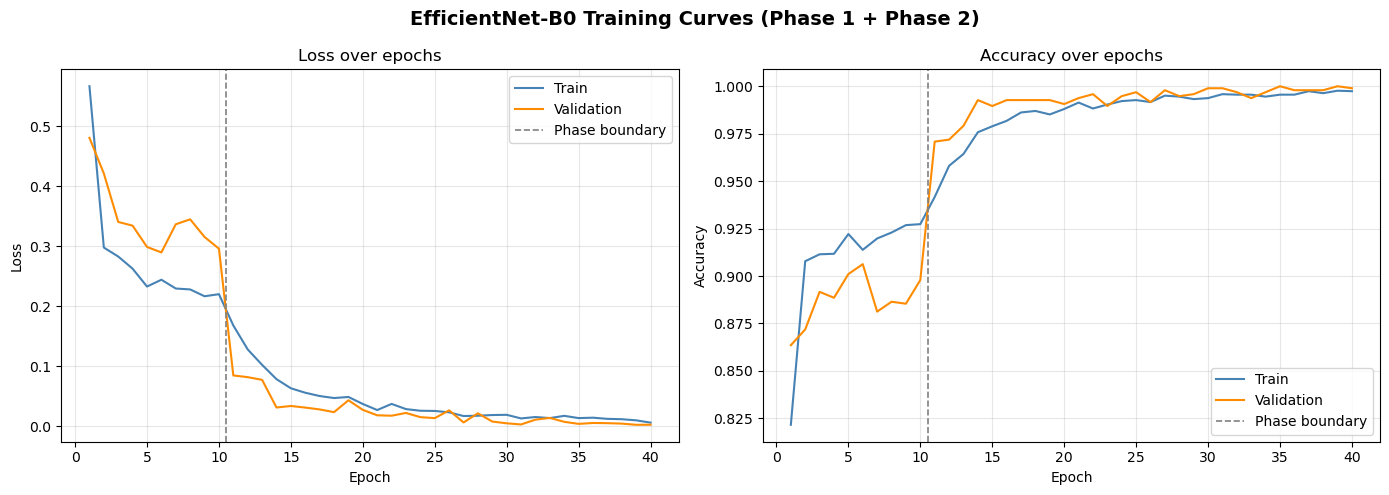

Saved: /Users/michelangelonardi/Desktop/Università/Master/BocconiMaster/Year2/Semester2_UW/AI_for_Agriculture/FinalProject/AI_agri_project/results/efficientnet_training_curves.png


In [15]:
# ── Load best EfficientNet weights ────────────────────────────────────────────
effnet.load_state_dict(torch.load(EN_SAVE_PATH, map_location=device))
print('Best EfficientNet-B0 weights loaded.')

# ── Plot training curves (Phase 1 + Phase 2 combined) ────────────────────────
en_train_loss = en_history_p1['train_loss'] + en_history_p2['train_loss']
en_val_loss   = en_history_p1['val_loss']   + en_history_p2['val_loss']
en_train_acc  = en_history_p1['train_acc']  + en_history_p2['train_acc']
en_val_acc    = en_history_p1['val_acc']    + en_history_p2['val_acc']
en_p1_len     = len(en_history_p1['train_loss'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EfficientNet-B0 Training Curves (Phase 1 + Phase 2)', fontsize=14, fontweight='bold')

en_epochs_all = range(1, len(en_train_loss) + 1)

for ax, metric, ylabel in zip(
    axes,
    [(en_train_loss, en_val_loss),   (en_train_acc, en_val_acc)],
    ['Loss', 'Accuracy']
):
    train_m, val_m = metric
    ax.plot(en_epochs_all, train_m, label='Train',      color='steelblue')
    ax.plot(en_epochs_all, val_m,   label='Validation', color='darkorange')
    ax.axvline(en_p1_len + 0.5, color='gray', linestyle='--', linewidth=1.2, label='Phase boundary')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} over epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_path = RESULTS_DIR / 'efficientnet_training_curves.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')

## 5. Validation Evaluation & Model Selection

In [16]:
# ── Predictions on validation set ─────────────────────────────────────────────
rn_val_preds, rn_val_labels = get_predictions(resnet, val_loader, device)
en_val_preds, en_val_labels = get_predictions(effnet, val_loader, device)

print('ResNet-18 — Validation Classification Report')
print('-' * 50)
print(classification_report(rn_val_labels, rn_val_preds, target_names=CLASSES))

print('EfficientNet-B0 — Validation Classification Report')
print('-' * 50)
print(classification_report(en_val_labels, en_val_preds, target_names=CLASSES))

ResNet-18 — Validation Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

      cloudy       1.00      1.00      1.00       240
      desert       1.00      1.00      1.00       240
  green_area       1.00      1.00      1.00       240
       water       1.00      1.00      1.00       240

    accuracy                           1.00       960
   macro avg       1.00      1.00      1.00       960
weighted avg       1.00      1.00      1.00       960

EfficientNet-B0 — Validation Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

      cloudy       1.00      1.00      1.00       240
      desert       1.00      1.00      1.00       240
  green_area       1.00      1.00      1.00       240
       water       1.00      1.00      1.00       240

    accuracy                           1.00       960
   macro avg       1.00      1.00      1.

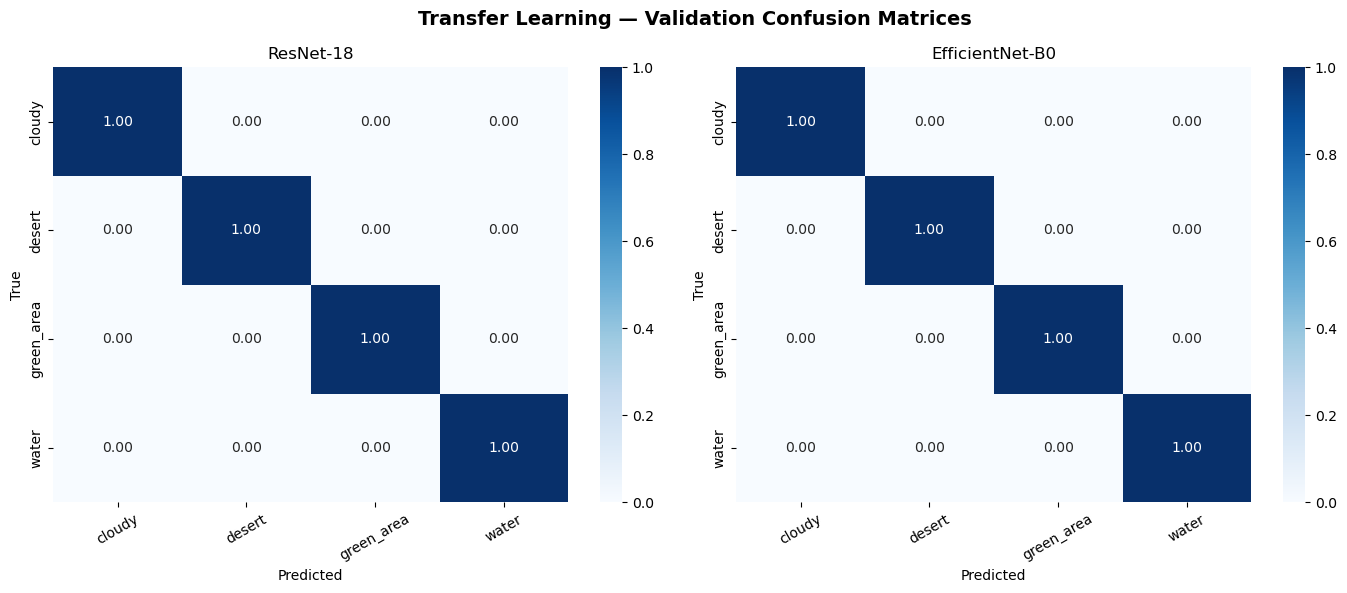

Saved: /Users/michelangelonardi/Desktop/Università/Master/BocconiMaster/Year2/Semester2_UW/AI_for_Agriculture/FinalProject/AI_agri_project/results/transfer_learning_val_confusion_matrices.png


In [17]:
# ── Side-by-side confusion matrices ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Transfer Learning — Validation Confusion Matrices', fontsize=14, fontweight='bold')

model_configs = [
    ('ResNet-18',       rn_val_labels, rn_val_preds),
    ('EfficientNet-B0', en_val_labels, en_val_preds),
]

for ax, (model_name, true_labels, pred_labels) in zip(axes, model_configs):
    cm = confusion_matrix(true_labels, pred_labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=CLASSES, yticklabels=CLASSES,
        ax=ax, vmin=0, vmax=1
    )
    ax.set_title(model_name, fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
save_path = RESULTS_DIR / 'transfer_learning_val_confusion_matrices.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')

In [18]:
# ── Summary DataFrame ─────────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(true_labels, pred_labels):
    acc = accuracy_score(true_labels, pred_labels)
    f1  = f1_score(true_labels, pred_labels, average='weighted')
    return acc, f1

rn_acc, rn_f1 = compute_metrics(rn_val_labels, rn_val_preds)
en_acc, en_f1 = compute_metrics(en_val_labels, en_val_preds)

summary_df = pd.DataFrame({
    'Model':        ['ResNet-18', 'EfficientNet-B0'],
    'Val Accuracy': [rn_acc,      en_acc],
    'Val F1 (weighted)': [rn_f1,  en_f1],
})

print('\nTransfer Learning — Validation Summary')
print(summary_df.to_string(index=False, float_format='{:.4f}'.format))

# Model selection
best_idx   = summary_df['Val Accuracy'].idxmax()
best_model_name = summary_df.loc[best_idx, 'Model']
best_acc        = summary_df.loc[best_idx, 'Val Accuracy']

print(f'\nSelected best transfer learning model: {best_model_name}  '
      f'(val accuracy = {best_acc:.4f})')


Transfer Learning — Validation Summary
          Model  Val Accuracy  Val F1 (weighted)
      ResNet-18        1.0000             1.0000
EfficientNet-B0        1.0000             1.0000

Selected best transfer learning model: ResNet-18  (val accuracy = 1.0000)


## 6. Summary

In [19]:
print('=' * 65)
print('  NOTEBOOK 05 — TRANSFER LEARNING SUMMARY')
print('=' * 65)
print(f'  Classes          : {CLASSES}')
print(f'  Train samples    : {len(X_train)}')
print(f'  Val samples      : {len(X_val)}')
print(f'  Test samples     : {len(X_test)}  (not yet evaluated)')
print('-' * 65)
print(f'  {"Model":<20} {"Val Accuracy":>14} {"Val F1 (wtd)":>14}')
print('-' * 65)
for _, row in summary_df.iterrows():
    print(f'  {row["Model"]:<20} {row["Val Accuracy"]:>14.4f} {row["Val F1 (weighted)"]:>14.4f}')
print('-' * 65)
print(f'  Best model       : {best_model_name}')
print('=' * 65)
print()
print('Saved artefacts:')
print(f'  {RESULTS_DIR / "best_resnet18_model.pth"}')
print(f'  {RESULTS_DIR / "best_efficientnet_model.pth"}')
print(f'  {RESULTS_DIR / "resnet18_training_curves.png"}')
print(f'  {RESULTS_DIR / "efficientnet_training_curves.png"}')
print(f'  {RESULTS_DIR / "transfer_learning_val_confusion_matrices.png"}')
print()
print('Note: Final test-set evaluation is deferred to Notebook 06.')

  NOTEBOOK 05 — TRANSFER LEARNING SUMMARY
  Classes          : ['cloudy', 'desert', 'green_area', 'water']
  Train samples    : 3840
  Val samples      : 960
  Test samples     : 1200  (not yet evaluated)
-----------------------------------------------------------------
  Model                  Val Accuracy   Val F1 (wtd)
-----------------------------------------------------------------
  ResNet-18                    1.0000         1.0000
  EfficientNet-B0              1.0000         1.0000
-----------------------------------------------------------------
  Best model       : ResNet-18

Saved artefacts:
  /Users/michelangelonardi/Desktop/Università/Master/BocconiMaster/Year2/Semester2_UW/AI_for_Agriculture/FinalProject/AI_agri_project/results/best_resnet18_model.pth
  /Users/michelangelonardi/Desktop/Università/Master/BocconiMaster/Year2/Semester2_UW/AI_for_Agriculture/FinalProject/AI_agri_project/results/best_efficientnet_model.pth
  /Users/michelangelonardi/Desktop/Università/Mast